In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/test_vienna60_annotated.csv")

# Basic cleanup
df = df.dropna(subset=["kl_60", "predicted_MFE"]).copy()
df["kl_60"] = pd.to_numeric(df["kl_60"], errors="coerce")
df["predicted_MFE"] = pd.to_numeric(df["predicted_MFE"], errors="coerce")
df = df.dropna(subset=["kl_60", "predicted_MFE"])

df.head()

,exon,num_DNA_reads,num_exon_inclusion,num_exon_skipping,num_intron_retention,num_splicing_in_exon,num_bad_exon1,num_bad_reads,num_unknown_splicing,total_noncanonical,...,st_predicted_prob,predicted_secondary_struct,predicted_MFE,model_sequence,wobble_count,flanks_added,predicted_PSI_60,kl_60,freq_MFE,ensemble_diversity
0,CTCACGTCCAACCCCGGCCGAAGTGGTGTTAGGCCGCAAATTGTAC...,13,83,158,0,0,3,1,10,14,...,0.162405,.........................((((((.(((((((.....((...,-10.32,CATCCAGGTTCTCACGTCCAACCCCGGCCGAAGTGGTGTTAGGCCG...,4,True,0.639778,0.179302,0.020607,10.11
1,CCCTCCTTAACCTCCAAGTGCTTTACTGGCGCTGCCTACAATTCCA...,16,56,15,0,0,0,0,4,4,...,0.155897,...((..((((...............((((((.....))))))......,-6.42,CATCCAGGTTCCCTCCTTAACCTCCAAGTGCTTTACTGGCGCTGCC...,6,True,0.707430,0.017021,0.008963,18.10
2,ACACTCCGCAGCACACTCGGCAAAGAAGTTAGGCCCCGCTCTTACA...,6,0,143,0,0,1,0,3,4,...,0.051171,.....................................((((((((....,-4.64,CATCCAGGTTACACTCCGCAGCACACTCGGCAAAGAAGTTAGGCCC...,8,True,0.007627,0.007647,0.017081,12.23
3,ACCCACAAAACGCAATTTACACCCAATACCACAGGGGGCGAACATA...,25,9,373,0,0,1,0,14,15,...,0.065669,..(((((.............(((........(((..........))...,-2.85,CATCCAGGTTACCCACAAAACGCAATTTACACCCAATACCACAGGG...,2,True,0.025151,0.000053,0.021267,18.61
4,GGTAGTACGCCAATTCGCCGGTGCCGCGAGCCAGAGGCTACCAAAA...,37,328,6,0,2,2,1,11,14,...,0.214096,....((((((((((((.......(((((.......))))).........,-9.94,CATCCAGGTTGGTAGTACGCCAATTCGCCGGTGCCGCGAGCCAGAG...,6,True,0.964427,0.005495,0.013731,18.29


In [3]:
# Bin predicted_MFE into quantile bins
n_bins = 20

df["mfe_bin"] = pd.qcut(
    df["predicted_MFE"],
    q=n_bins,
    labels=False,
    duplicates="drop"
)

# Human-readable bin labels
bin_edges = pd.qcut(
    df["predicted_MFE"],
    q=n_bins,
    duplicates="drop"
).cat.categories

df["mfe_bin_label"] = pd.qcut(
    df["predicted_MFE"],
    q=n_bins,
    duplicates="drop"
)

df[["predicted_MFE", "mfe_bin", "mfe_bin_label", "kl_60"]].head()

,predicted_MFE,mfe_bin,mfe_bin_label,kl_60
0,-10.32,1,"(-11.71, -10.16]",0.179302
1,-6.42,7,"(-6.61, -6.13]",0.017021
2,-4.64,11,"(-4.83, -4.4]",0.007647
3,-2.85,15,"(-3.13, -2.67]",0.000053
4,-9.94,2,"(-10.16, -9.16]",0.005495


In [4]:
# Summary statistics by MFE bin
summary = (
    df.groupby("mfe_bin_label", observed=True)
    .agg(
        count=("kl_60", "size"),
        mean_kl=("kl_60", "mean"),
        median_kl=("kl_60", "median"),
        p90_kl=("kl_60", lambda x: x.quantile(0.90)),
        p95_kl=("kl_60", lambda x: x.quantile(0.95)),
        mean_mfe=("predicted_MFE", "mean"),
    )
    .reset_index()
)

summary

,mfe_bin_label,count,mean_kl,median_kl,p90_kl,p95_kl,mean_mfe
0,"(-26.141000000000002, -11.71]",2410,0.214612,0.020597,0.684604,1.229851,-13.755689
1,"(-11.71, -10.16]",2395,0.167101,0.018731,0.488529,0.977049,-10.861545
2,"(-10.16, -9.16]",2410,0.124242,0.017550,0.354509,0.653615,-9.628560
3,"(-9.16, -8.39]",2386,0.114695,0.017492,0.350783,0.625642,-8.758064
4,"(-8.39, -7.72]",2394,0.104382,0.016649,0.301074,0.557051,-8.036579
5,"(-7.72, -7.12]",2419,0.112335,0.017749,0.320932,0.585257,-7.411203
6,"(-7.12, -6.61]",2400,0.095815,0.017461,0.270407,0.497599,-6.851587
7,"(-6.61, -6.13]",2384,0.104142,0.018477,0.300504,0.539763,-6.364996
8,"(-6.13, -5.68]",2391,0.091786,0.018473,0.265854,0.460903,-5.897470
9,"(-5.68, -5.25]",2416,0.079352,0.017671,0.217936,0.379321,-5.453829


In [5]:
# Summary statistics by MFE bin
summary = (
    df.groupby("mfe_bin_label", observed=True)
    .agg(
        count=("kl_60", "size"),
        mean_kl=("kl_60", "mean"),
        median_kl=("kl_60", "median"),
        p90_kl=("kl_60", lambda x: x.quantile(0.90)),
        p95_kl=("kl_60", lambda x: x.quantile(0.95)),
        mean_mfe=("predicted_MFE", "mean"),
    )
    .reset_index()
)

summary

,mfe_bin_label,count,mean_kl,median_kl,p90_kl,p95_kl,mean_mfe
0,"(-26.141000000000002, -11.71]",2410,0.214612,0.020597,0.684604,1.229851,-13.755689
1,"(-11.71, -10.16]",2395,0.167101,0.018731,0.488529,0.977049,-10.861545
2,"(-10.16, -9.16]",2410,0.124242,0.017550,0.354509,0.653615,-9.628560
3,"(-9.16, -8.39]",2386,0.114695,0.017492,0.350783,0.625642,-8.758064
4,"(-8.39, -7.72]",2394,0.104382,0.016649,0.301074,0.557051,-8.036579
5,"(-7.72, -7.12]",2419,0.112335,0.017749,0.320932,0.585257,-7.411203
6,"(-7.12, -6.61]",2400,0.095815,0.017461,0.270407,0.497599,-6.851587
7,"(-6.61, -6.13]",2384,0.104142,0.018477,0.300504,0.539763,-6.364996
8,"(-6.13, -5.68]",2391,0.091786,0.018473,0.265854,0.460903,-5.897470
9,"(-5.68, -5.25]",2416,0.079352,0.017671,0.217936,0.379321,-5.453829


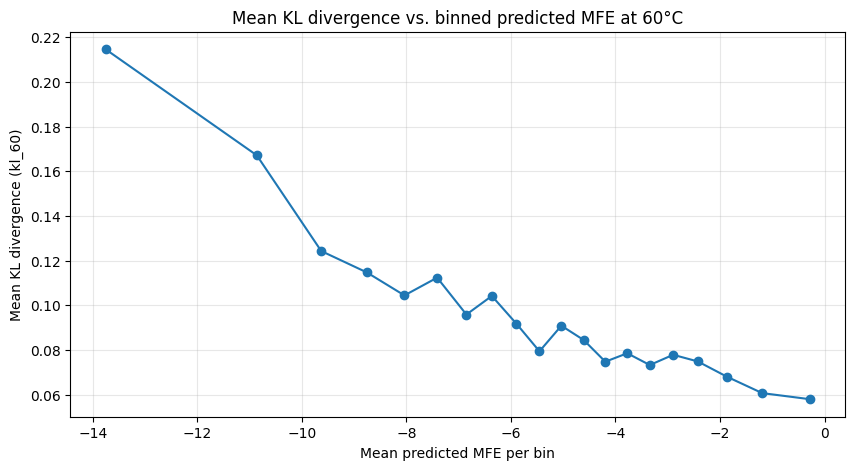

In [6]:
# Plot mean KL by predicted MFE bin
plt.figure(figsize=(10, 5))
plt.plot(summary["mean_mfe"], summary["mean_kl"], marker="o")
plt.xlabel("Mean predicted MFE per bin")
plt.ylabel("Mean KL divergence (kl_60)")
plt.title("Mean KL divergence vs. binned predicted MFE at 60°C")
plt.grid(True, alpha=0.3)
plt.show()

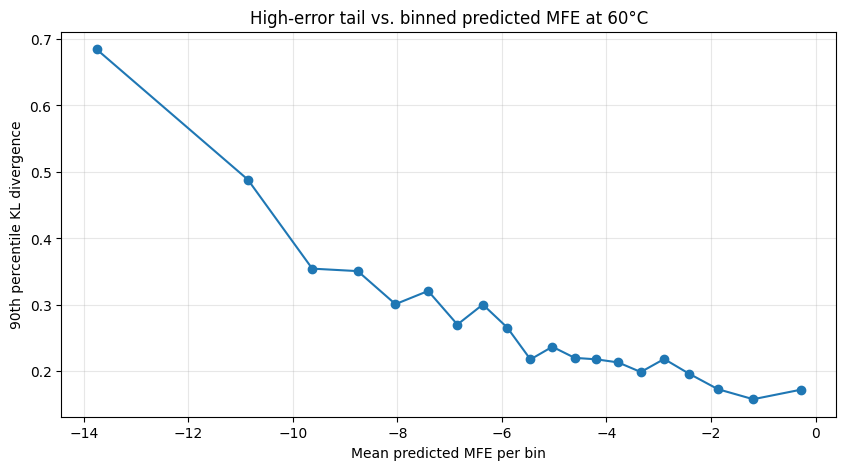

In [7]:
# Plot high-error tail: 90th percentile KL by MFE bin
plt.figure(figsize=(10, 5))
plt.plot(summary["mean_mfe"], summary["p90_kl"], marker="o")
plt.xlabel("Mean predicted MFE per bin")
plt.ylabel("90th percentile KL divergence")
plt.title("High-error tail vs. binned predicted MFE at 60°C")
plt.grid(True, alpha=0.3)
plt.show()

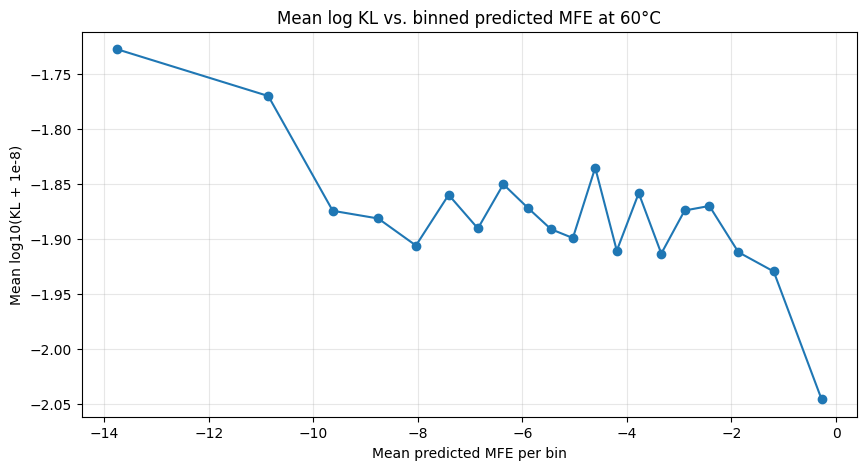

In [8]:
# Log-scale version, useful because KL is usually heavy-tailed
df["log_kl_60"] = np.log10(df["kl_60"] + 1e-8)

log_summary = (
    df.groupby("mfe_bin_label", observed=True)
    .agg(
        count=("log_kl_60", "size"),
        mean_log_kl=("log_kl_60", "mean"),
        median_log_kl=("log_kl_60", "median"),
        p90_log_kl=("log_kl_60", lambda x: x.quantile(0.90)),
        mean_mfe=("predicted_MFE", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(log_summary["mean_mfe"], log_summary["mean_log_kl"], marker="o")
plt.xlabel("Mean predicted MFE per bin")
plt.ylabel("Mean log10(KL + 1e-8)")
plt.title("Mean log KL vs. binned predicted MFE at 60°C")
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1400x500 with 0 Axes>

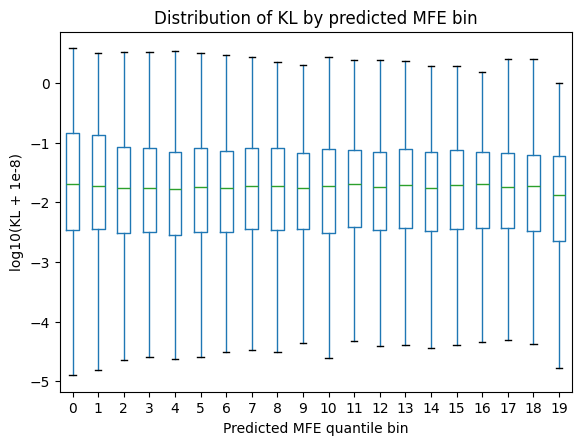

In [9]:
# Boxplot / distribution view across bins
plt.figure(figsize=(14, 5))
df.boxplot(
    column="log_kl_60",
    by="mfe_bin",
    grid=False,
    showfliers=False
)
plt.xlabel("Predicted MFE quantile bin")
plt.ylabel("log10(KL + 1e-8)")
plt.title("Distribution of KL by predicted MFE bin")
plt.suptitle("")
plt.show()

In [10]:
# Check whether lower MFE bins have larger KL
lowest_mfe_bin = summary.iloc[summary["mean_mfe"].idxmin()]
highest_mfe_bin = summary.iloc[summary["mean_mfe"].idxmax()]

print("Lowest MFE bin:")
print(lowest_mfe_bin)

print("\nHighest MFE bin:")
print(highest_mfe_bin)

ratio = lowest_mfe_bin["mean_kl"] / highest_mfe_bin["mean_kl"]
print(f"\nMean KL ratio, lowest MFE bin / highest MFE bin: {ratio:.3f}")

Lowest MFE bin:
mfe_bin_label    (-26.141000000000002, -11.71]
count                                     2410
mean_kl                               0.214612
median_kl                             0.020597
p90_kl                                0.684604
p95_kl                                1.229851
mean_mfe                            -13.755689
Name: 0, dtype: object

Highest MFE bin:
mfe_bin_label    (-0.78, 0.0]
count                    2378
mean_kl              0.057899
median_kl            0.013185
p90_kl               0.172444
p95_kl               0.280972
mean_mfe            -0.276905
Name: 19, dtype: object

Mean KL ratio, lowest MFE bin / highest MFE bin: 3.707


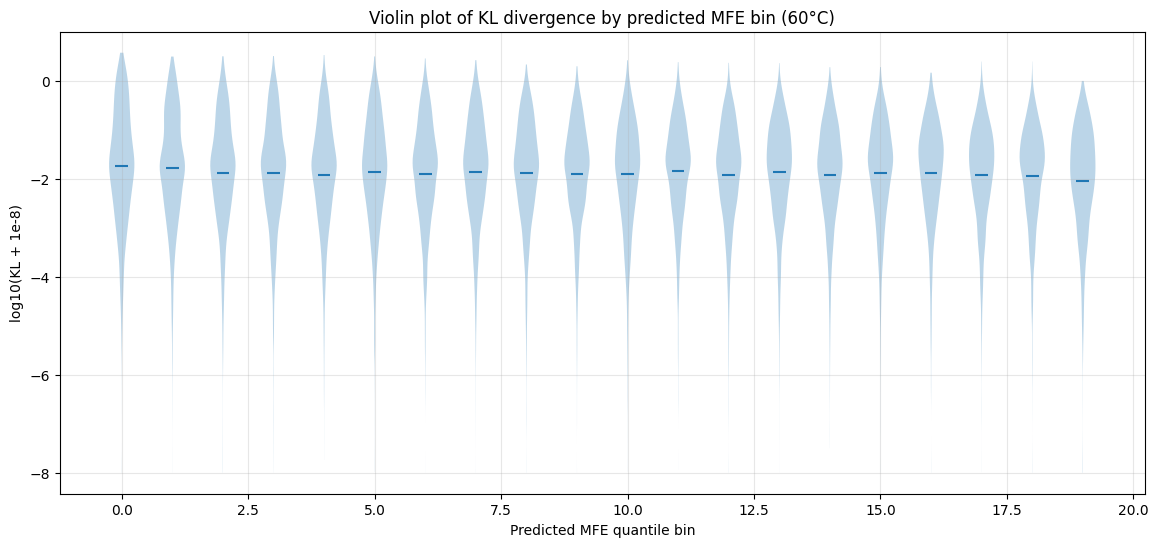

In [11]:
# Violin plot of KL distributions across predicted MFE bins

plt.figure(figsize=(14, 6))

# Build grouped data in bin order
grouped_data = [
    df[df["mfe_bin"] == b]["log_kl_60"].values
    for b in sorted(df["mfe_bin"].dropna().unique())
]

positions = sorted(df["mfe_bin"].dropna().unique())

plt.violinplot(
    grouped_data,
    positions=positions,
    showmeans=True,
    showmedians=False,
    showextrema=False
)

plt.xlabel("Predicted MFE quantile bin")
plt.ylabel("log10(KL + 1e-8)")
plt.title("Violin plot of KL divergence by predicted MFE bin (60°C)")

plt.grid(True, alpha=0.3)
plt.show()

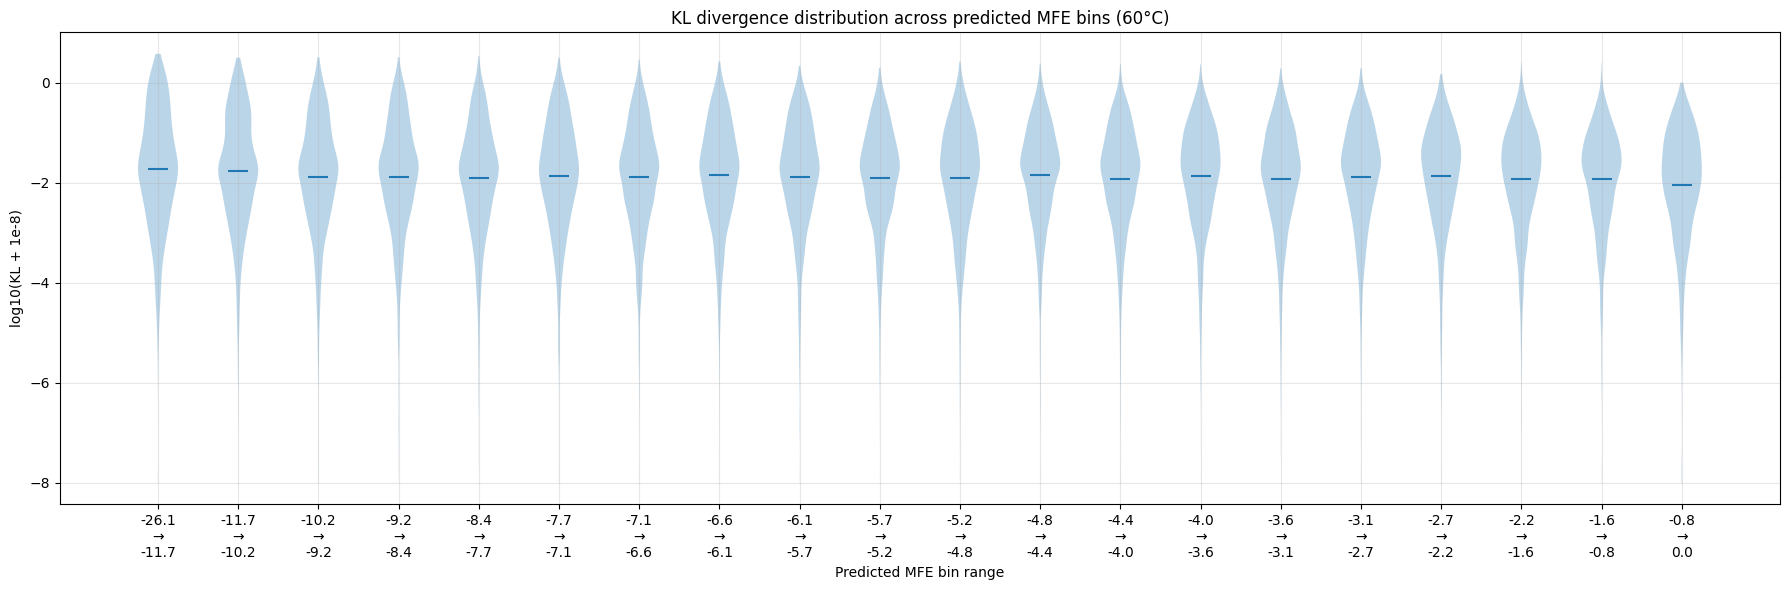

In [12]:
# Violin plot with actual MFE ranges as labels

plt.figure(figsize=(18, 6))

grouped_data = [
    df[df["mfe_bin"] == b]["log_kl_60"].values
    for b in sorted(df["mfe_bin"].dropna().unique())
]

positions = range(len(grouped_data))

plt.violinplot(
    grouped_data,
    positions=positions,
    showmeans=True,
    showmedians=False,
    showextrema=False
)

# Build readable labels
labels = [
    f"{interval.left:.1f}\n→\n{interval.right:.1f}"
    for interval in summary["mfe_bin_label"]
]

plt.xticks(positions, labels, rotation=0)

plt.xlabel("Predicted MFE bin range")
plt.ylabel("log10(KL + 1e-8)")
plt.title("KL divergence distribution across predicted MFE bins (60°C)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

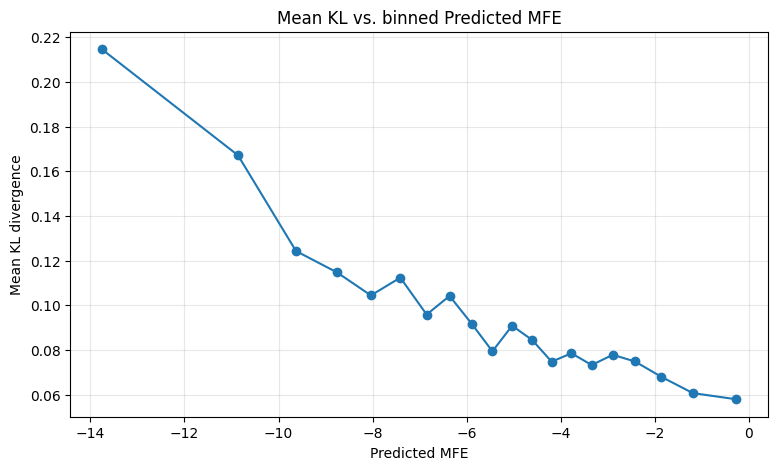

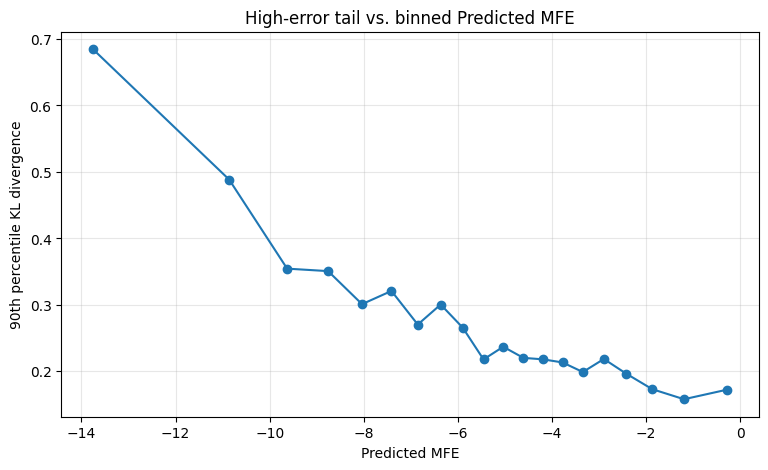

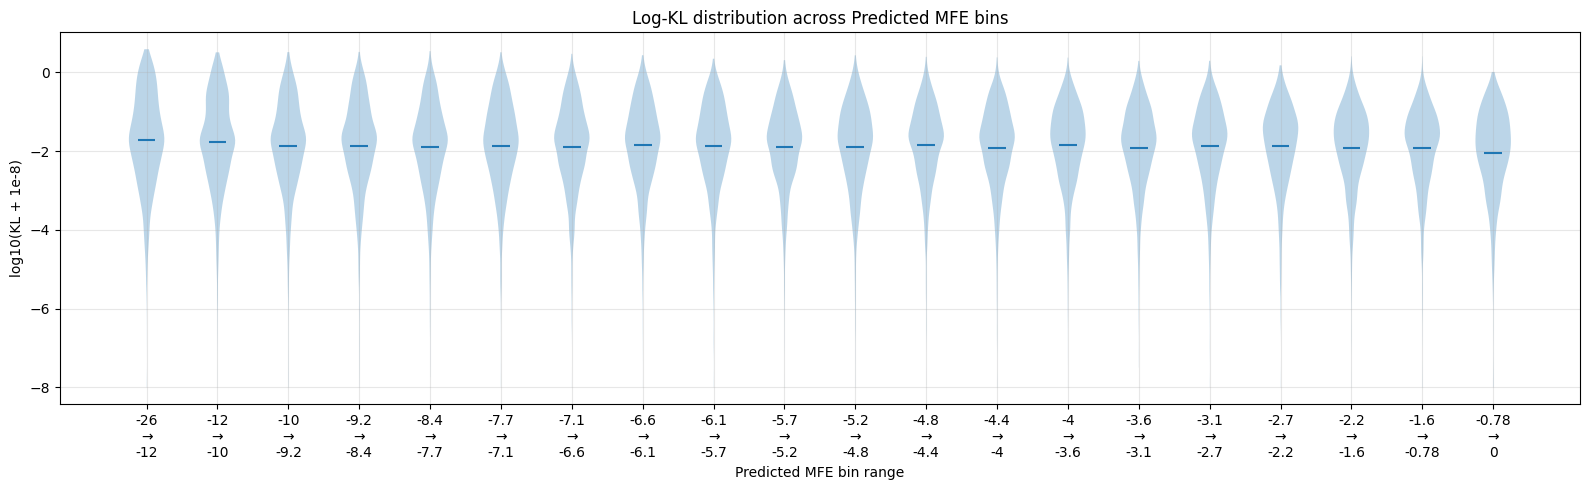

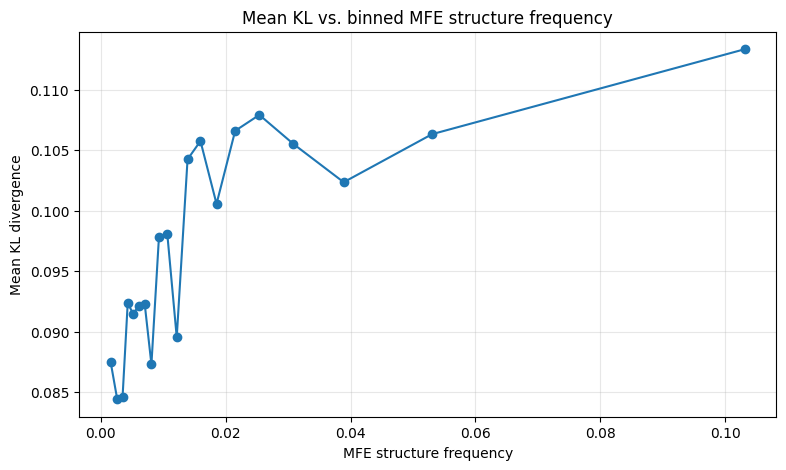

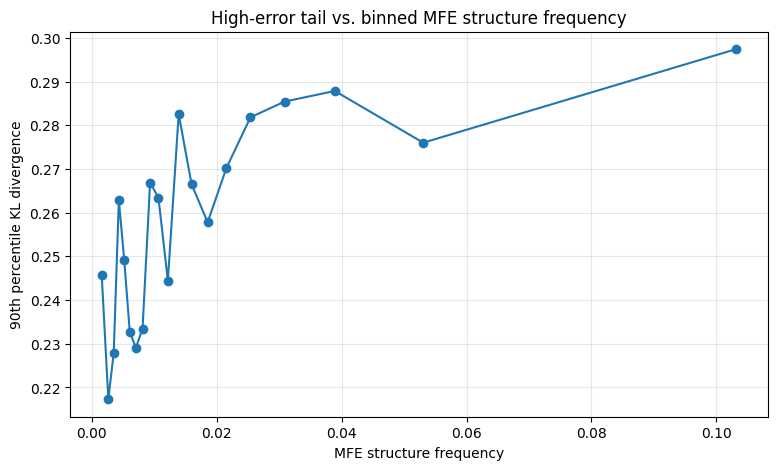

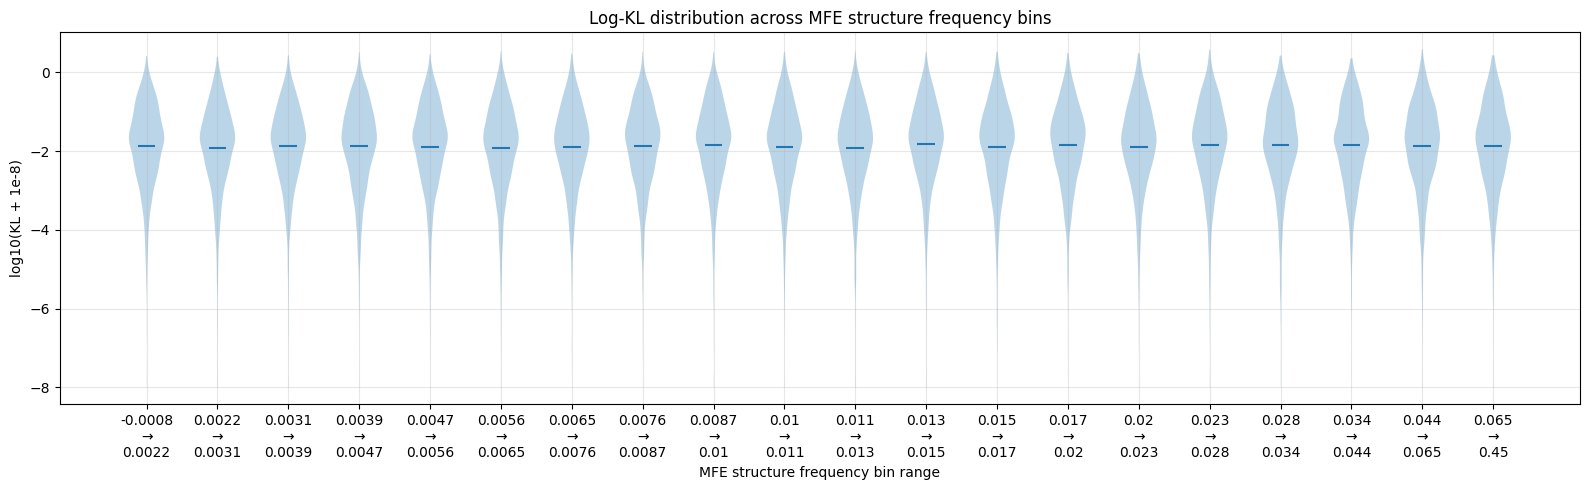

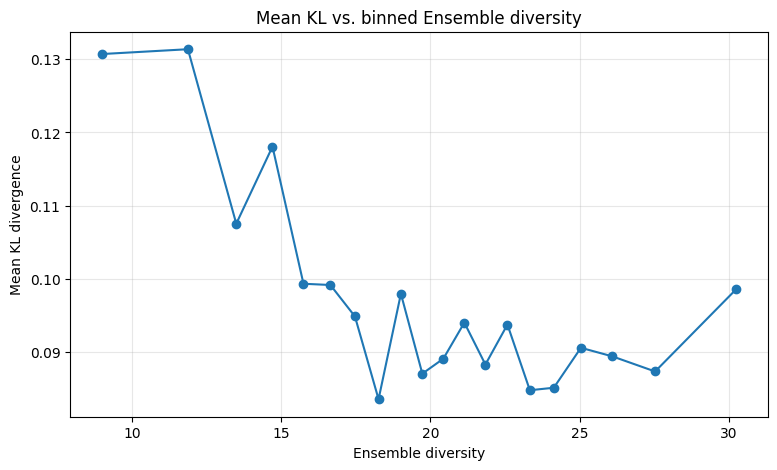

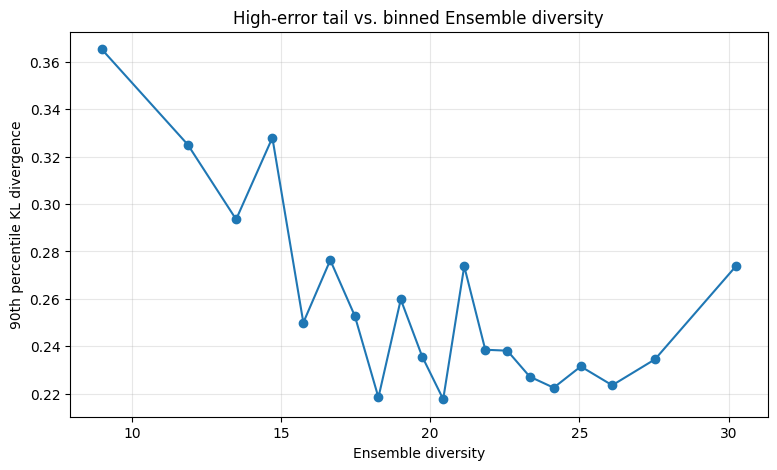

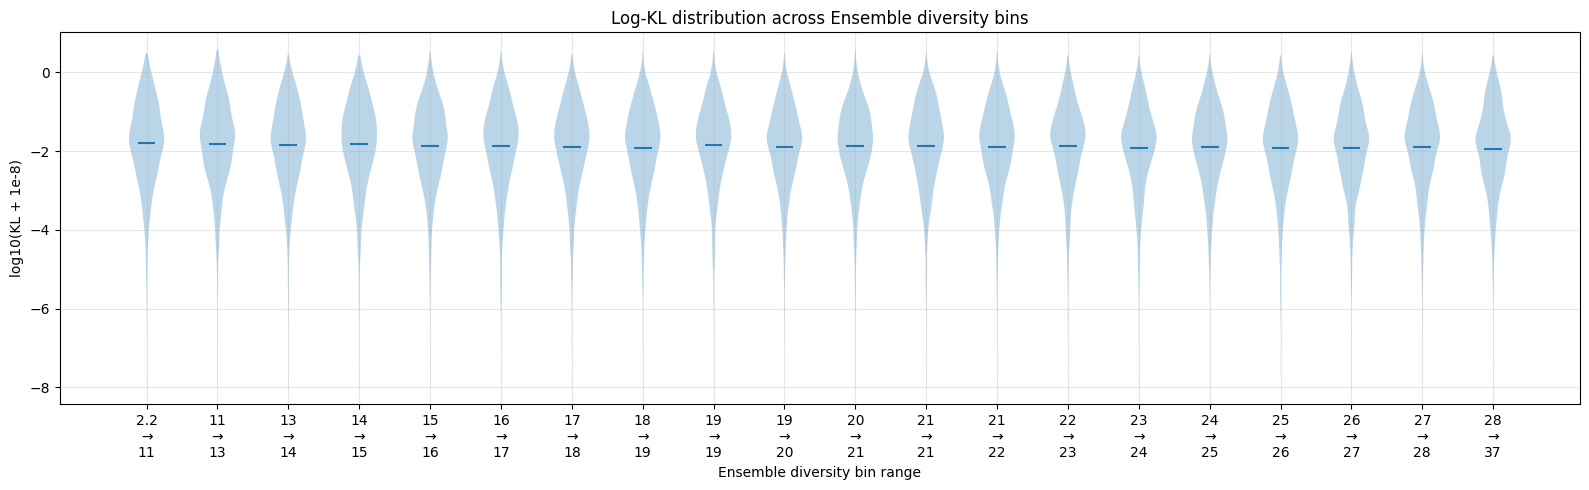

In [13]:
features = {
    "predicted_MFE": "Predicted MFE",
    "freq_MFE": "MFE structure frequency",
    "ensemble_diversity": "Ensemble diversity",
}

kl_col = "kl_60"
eps = 1e-8
n_bins = 20

df[kl_col] = pd.to_numeric(df[kl_col], errors="coerce")
df["log_kl"] = np.log10(df[kl_col] + eps)

for feature, feature_label in features.items():
    df[feature] = pd.to_numeric(df[feature], errors="coerce")
    
    tmp = df.dropna(subset=[feature, kl_col, "log_kl"]).copy()
    tmp["bin"] = pd.qcut(tmp[feature], q=n_bins, labels=False, duplicates="drop")
    tmp["bin_interval"] = pd.qcut(tmp[feature], q=n_bins, duplicates="drop")
    
    summary = (
        tmp.groupby("bin_interval", observed=True)
        .agg(
            count=(kl_col, "size"),
            mean_feature=(feature, "mean"),
            mean_kl=(kl_col, "mean"),
            median_kl=(kl_col, "median"),
            p90_kl=(kl_col, lambda x: x.quantile(0.90)),
            mean_log_kl=("log_kl", "mean"),
        )
        .reset_index()
    )
    
    # Mean KL plot
    plt.figure(figsize=(9, 5))
    plt.plot(summary["mean_feature"], summary["mean_kl"], marker="o")
    plt.xlabel(feature_label)
    plt.ylabel("Mean KL divergence")
    plt.title(f"Mean KL vs. binned {feature_label}")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 90th percentile KL plot
    plt.figure(figsize=(9, 5))
    plt.plot(summary["mean_feature"], summary["p90_kl"], marker="o")
    plt.xlabel(feature_label)
    plt.ylabel("90th percentile KL divergence")
    plt.title(f"High-error tail vs. binned {feature_label}")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Violin plot
    bins = sorted(tmp["bin"].dropna().unique())
    grouped_data = [tmp[tmp["bin"] == b]["log_kl"].values for b in bins]
    
    labels = []
    for interval in summary["bin_interval"]:
        labels.append(f"{interval.left:.2g}\n→\n{interval.right:.2g}")
    
    plt.figure(figsize=(16, 5))
    plt.violinplot(
        grouped_data,
        positions=range(len(grouped_data)),
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )
    plt.xticks(range(len(labels)), labels, rotation=0)
    plt.xlabel(f"{feature_label} bin range")
    plt.ylabel("log10(KL + 1e-8)")
    plt.title(f"Log-KL distribution across {feature_label} bins")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

===== SUMMARY STATS =====

--- PSI ---
count    47962.000000
mean         0.605620
std          0.427101
min          0.000000
25%          0.056180
50%          0.892857
75%          0.982301
max          1.000000
Name: PSI, dtype: float64

--- predicted_PSI ---
count    4.796200e+04
mean     6.068697e-01
std      3.825491e-01
min      4.250500e-07
25%      1.861190e-01
50%      7.854340e-01
75%      9.625202e-01
max      9.883380e-01
Name: predicted_PSI, dtype: float64

--- kl ---
count    47962.000000
mean         0.099904
std          0.228122
min          0.000000
25%          0.003590
50%          0.020299
75%          0.088034
max          3.724001
Name: kl, dtype: float64

--- predicted_mfe ---
count    47962.000000
mean       -16.115657
std          5.103622
min        -42.000000
25%        -19.400000
50%        -15.800000
75%        -12.500000
max         -1.000000
Name: predicted_mfe, dtype: float64



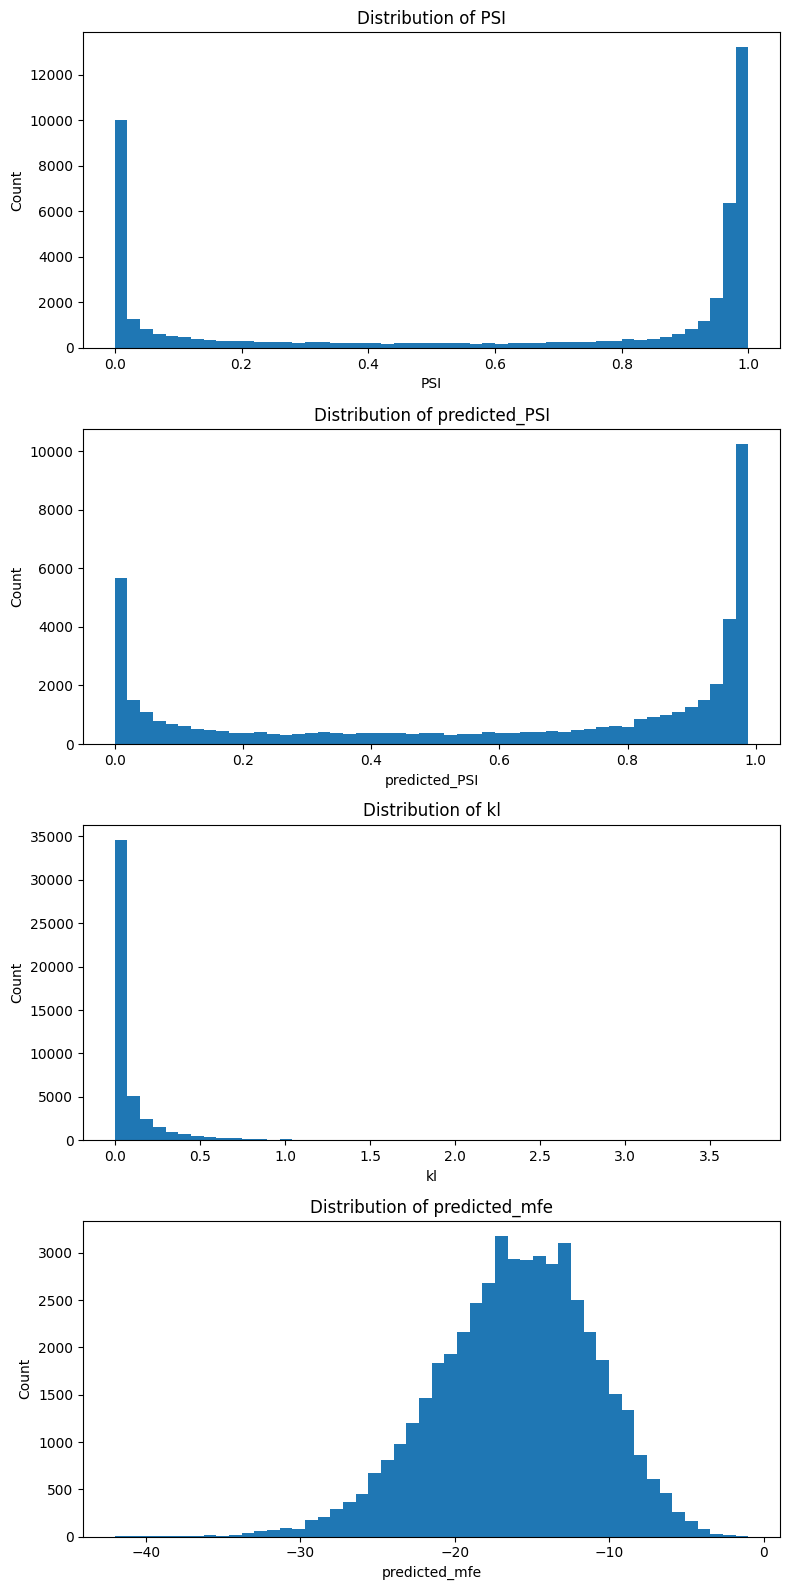

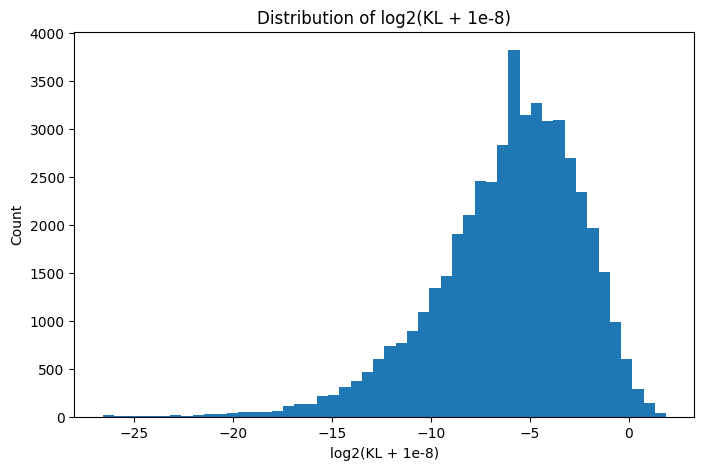

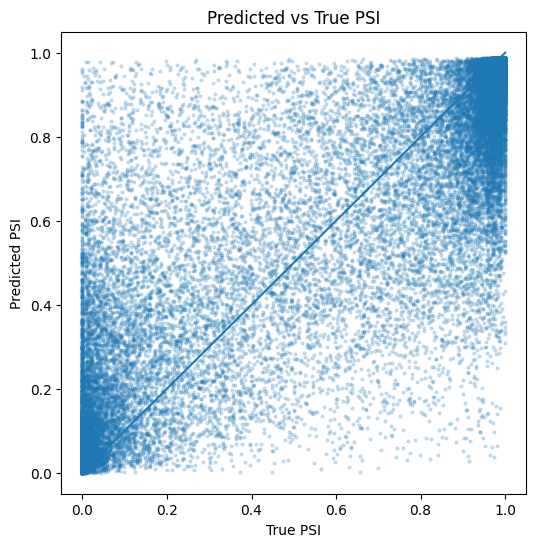

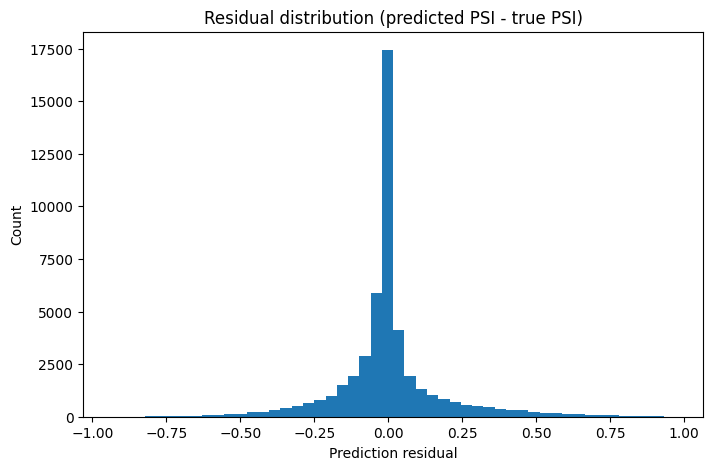

Residual mean: 0.0012492084864960686
Residual median: -0.004588417725381377


In [21]:
# distribution inspection of datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load CSV
# =========================
df = pd.read_csv("../data/test_data_rna_structure.csv")

# =========================
# Columns to inspect
# =========================
cols = [
    "PSI",
    "predicted_PSI",
    "kl",
    "predicted_mfe",
]
# =========================
# Basic statistics
# =========================
print("===== SUMMARY STATS =====\n")

for col in cols:
    if col not in df.columns:
        continue

    x = pd.to_numeric(df[col], errors="coerce").dropna()

    print(f"--- {col} ---")
    print(x.describe())
    print()

# =========================
# Histograms
# =========================
n = len(cols)

fig, axes = plt.subplots(n, 1, figsize=(8, 4*n))

if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols):

    x = pd.to_numeric(df[col], errors="coerce").dropna()

    ax.hist(x, bins=50)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# =========================
# Log-KL distribution
# =========================
if "kl" in df.columns:

    kl = pd.to_numeric(df["kl"], errors="coerce").dropna()

    log2_kl = np.log2(kl + 1e-8)

    plt.figure(figsize=(8,5))
    plt.hist(log2_kl, bins=50)

    plt.title("Distribution of log2(KL + 1e-8)")
    plt.xlabel("log2(KL + 1e-8)")
    plt.ylabel("Count")

    plt.show()

# =========================
# PSI vs prediction scatter
# =========================
if "predicted_PSI" in df.columns:

    psi = pd.to_numeric(df["PSI"], errors="coerce")
    pred = pd.to_numeric(df["predicted_PSI"], errors="coerce")

    valid = (~psi.isna()) & (~pred.isna())

    plt.figure(figsize=(6,6))

    plt.scatter(
        psi[valid],
        pred[valid],
        s=4,
        alpha=0.2
    )

    plt.plot([0,1], [0,1])

    plt.xlabel("True PSI")
    plt.ylabel("Predicted PSI")
    plt.title("Predicted vs True PSI")

    plt.show()

# =========================
# Residual distribution
# =========================
if "predicted_PSI" in df.columns:

    residual = pred - psi

    residual = residual.dropna()

    plt.figure(figsize=(8,5))

    plt.hist(residual, bins=50)

    plt.title("Residual distribution (predicted PSI - true PSI)")
    plt.xlabel("Prediction residual")
    plt.ylabel("Count")

    plt.show()

    print("Residual mean:", residual.mean())
    print("Residual median:", residual.median())

===== SUMMARY STATS =====

--- PSI ---
count    191846.000000
mean          0.608144
std           0.426719
min           0.000000
25%           0.058201
50%           0.897861
75%           0.982558
max           1.000000
Name: PSI, dtype: float64

--- predicted_PSI ---
count    1.918460e+05
mean     6.085019e-01
std      3.829007e-01
min      1.133172e-07
25%      1.870401e-01
50%      7.905664e-01
75%      9.633111e-01
max      9.883820e-01
Name: predicted_PSI, dtype: float64

--- predicted_MFE ---
count    191846.000000
mean        -16.124116
std           5.106489
min         -46.800000
25%         -19.400000
50%         -15.800000
75%         -12.500000
max          -0.600000
Name: predicted_MFE, dtype: float64



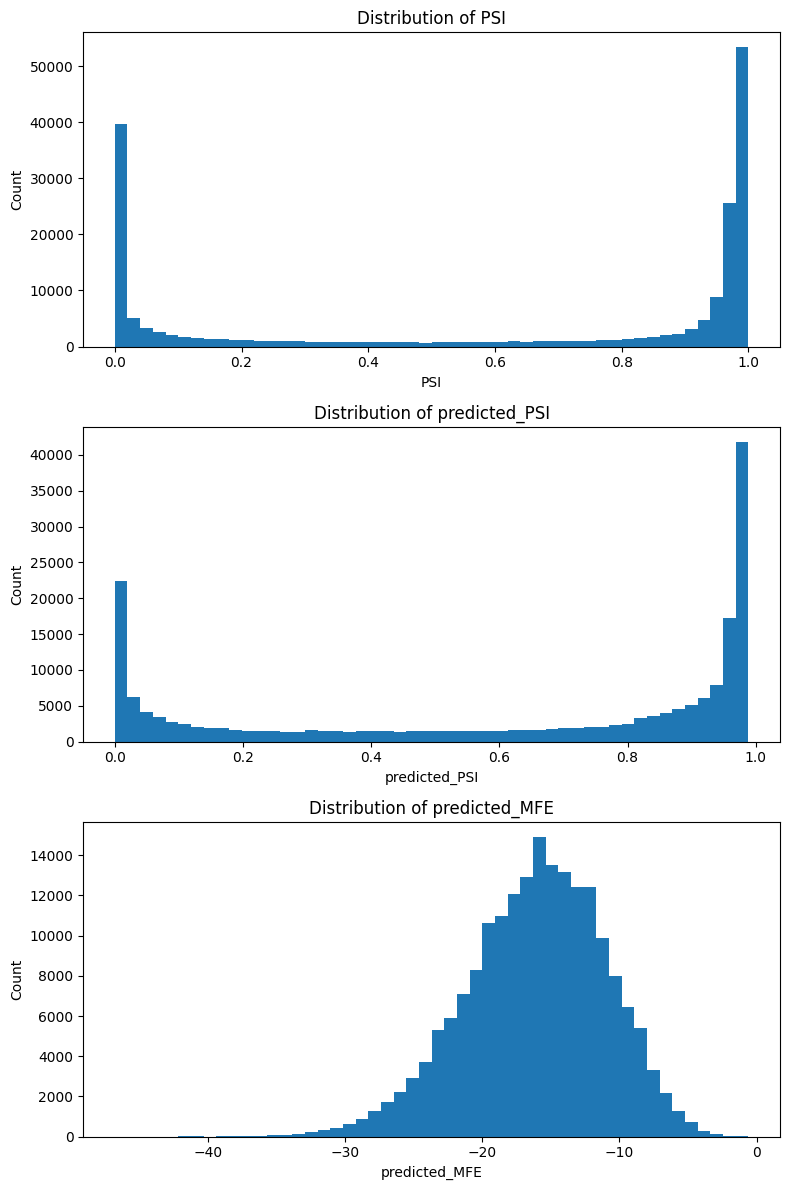

In [ ]:
# distribution inspection of datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load CSV
# =========================
df = pd.read_csv("../data/train_data.csv")

# =========================
# Columns to inspect
# =========================
cols = [
    "PSI",
    "predicted_PSI",
    "predicted_MFE",
]
# =========================
# Basic statistics
# =========================
print("===== SUMMARY STATS =====\n")

for col in cols:
    if col not in df.columns:
        continue

    x = pd.to_numeric(df[col], errors="coerce").dropna()

    print(f"--- {col} ---")
    print(x.describe())
    print()

# =========================
# Histograms
# =========================
n = len(cols)

fig, axes = plt.subplots(n, 1, figsize=(8, 4*n))

if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols):

    x = pd.to_numeric(df[col], errors="coerce").dropna()

    ax.hist(x, bins=50)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# =========================
# Log-KL distribution
# =========================
if "kl_60" in df.columns:

    kl = pd.to_numeric(df["kl_60"], errors="coerce").dropna()

    log2_kl = np.log2(kl + 1e-8)

    plt.figure(figsize=(8,5))
    plt.hist(log2_kl, bins=50)

    plt.title("Distribution of log2(KL + 1e-8)")
    plt.xlabel("log2(KL + 1e-8)")
    plt.ylabel("Count")

    plt.show()

# =========================
# PSI vs prediction scatter
# =========================
if "predicted_PSI_60" in df.columns:

    psi = pd.to_numeric(df["PSI"], errors="coerce")
    pred = pd.to_numeric(df["predicted_PSI_60"], errors="coerce")

    valid = (~psi.isna()) & (~pred.isna())

    plt.figure(figsize=(6,6))

    plt.scatter(
        psi[valid],
        pred[valid],
        s=4,
        alpha=0.2
    )

    plt.plot([0,1], [0,1])

    plt.xlabel("True PSI")
    plt.ylabel("Predicted PSI")
    plt.title("Predicted vs True PSI")

    plt.show()

# =========================
# Residual distribution
# =========================
if "predicted_PSI_60" in df.columns:

    residual = pred - psi

    residual = residual.dropna()

    plt.figure(figsize=(8,5))

    plt.hist(residual, bins=50)

    plt.title("Residual distribution (predicted PSI - true PSI)")
    plt.xlabel("Prediction residual")
    plt.ylabel("Count")

    plt.show()

    print("Residual mean:", residual.mean())
    print("Residual median:", residual.median())

===== SUMMARY STATS =====

--- PSI ---
count    47962.000000
mean         0.605620
std          0.427101
min          0.000000
25%          0.056180
50%          0.892857
75%          0.982301
max          1.000000
Name: PSI, dtype: float64

--- predicted_PSI_60 ---
count    4.796200e+04
mean     6.067329e-01
std      3.899366e-01
min      1.453853e-07
25%      1.634241e-01
50%      8.062093e-01
75%      9.634478e-01
max      9.939017e-01
Name: predicted_PSI_60, dtype: float64

--- kl_60 ---
count    47962.000000
mean         0.097506
std          0.238312
min          0.000000
25%          0.003346
50%          0.018168
75%          0.075819
max          3.838759
Name: kl_60, dtype: float64

--- predicted_MFE ---
count    47962.000000
mean        -5.636470
std          3.368977
min        -26.139999
25%         -7.720000
50%         -5.250000
75%         -3.130000
max          0.000000
Name: predicted_MFE, dtype: float64



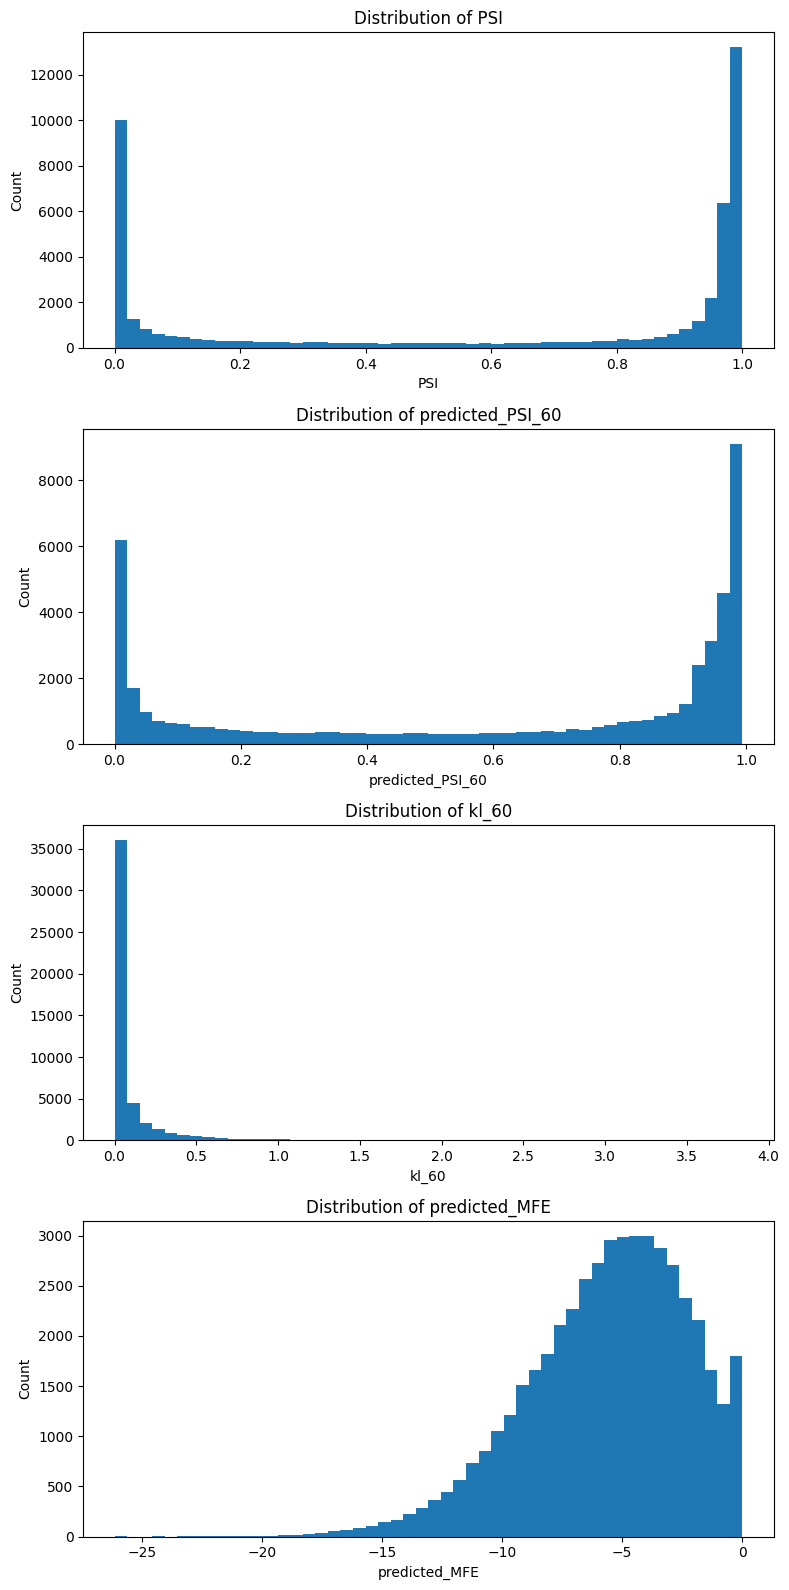

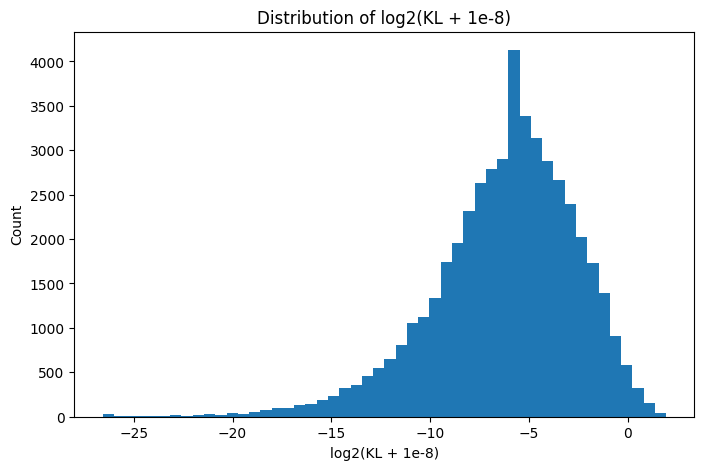

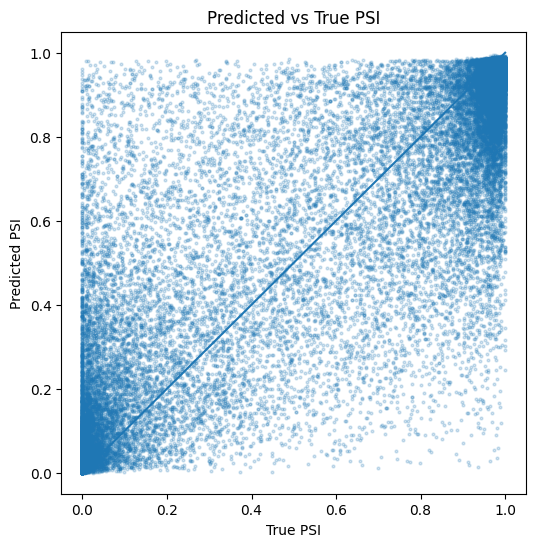

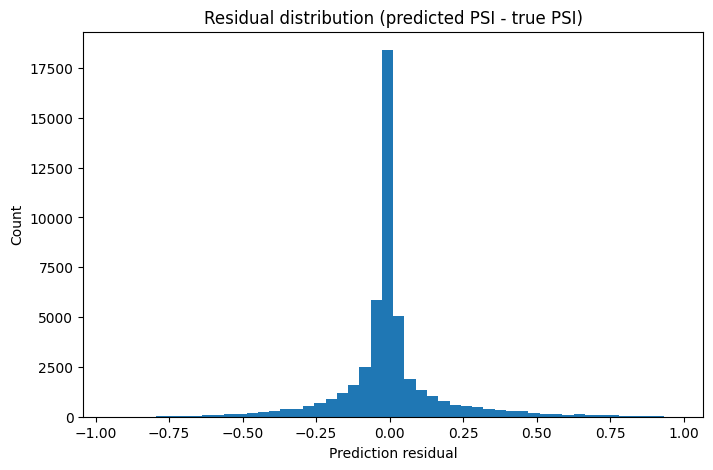

Residual mean: 0.0011124842829913389
Residual median: -0.004789651407665411


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load CSV
# =========================
df = pd.read_csv("../data/test_vienna60_annotated.csv")

# =========================
# Columns to inspect
# =========================
cols = [
    "PSI",
    "predicted_PSI_60",
    "kl_60",
    "predicted_MFE",
]
# =========================
# Basic statistics
# =========================
print("===== SUMMARY STATS =====\n")

for col in cols:
    if col not in df.columns:
        continue

    x = pd.to_numeric(df[col], errors="coerce").dropna()

    print(f"--- {col} ---")
    print(x.describe())
    print()

# =========================
# Histograms
# =========================
n = len(cols)

fig, axes = plt.subplots(n, 1, figsize=(8, 4*n))

if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols):

    x = pd.to_numeric(df[col], errors="coerce").dropna()

    ax.hist(x, bins=50)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# =========================
# Log-KL distribution
# =========================
if "kl_60" in df.columns:

    kl = pd.to_numeric(df["kl_60"], errors="coerce").dropna()

    log2_kl = np.log2(kl + 1e-8)

    plt.figure(figsize=(8,5))
    plt.hist(log2_kl, bins=50)

    plt.title("Distribution of log2(KL + 1e-8)")
    plt.xlabel("log2(KL + 1e-8)")
    plt.ylabel("Count")

    plt.show()

# =========================
# PSI vs prediction scatter
# =========================
if "predicted_PSI_60" in df.columns:

    psi = pd.to_numeric(df["PSI"], errors="coerce")
    pred = pd.to_numeric(df["predicted_PSI_60"], errors="coerce")

    valid = (~psi.isna()) & (~pred.isna())

    plt.figure(figsize=(6,6))

    plt.scatter(
        psi[valid],
        pred[valid],
        s=4,
        alpha=0.2
    )

    plt.plot([0,1], [0,1])

    plt.xlabel("True PSI")
    plt.ylabel("Predicted PSI")
    plt.title("Predicted vs True PSI")

    plt.show()

# =========================
# Residual distribution
# =========================
if "predicted_PSI_60" in df.columns:

    residual = pred - psi

    residual = residual.dropna()

    plt.figure(figsize=(8,5))

    plt.hist(residual, bins=50)

    plt.title("Residual distribution (predicted PSI - true PSI)")
    plt.xlabel("Prediction residual")
    plt.ylabel("Count")

    plt.show()

    print("Residual mean:", residual.mean())
    print("Residual median:", residual.median())

Vertical threshold at log2(0.1) = -3.321928094887362


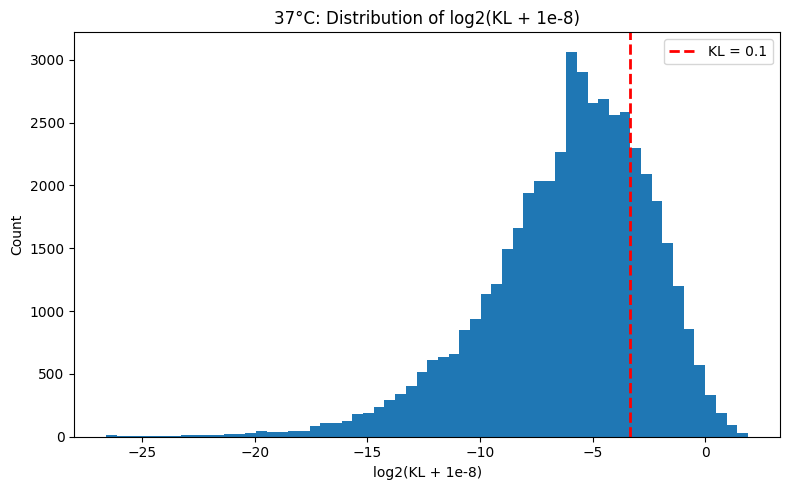

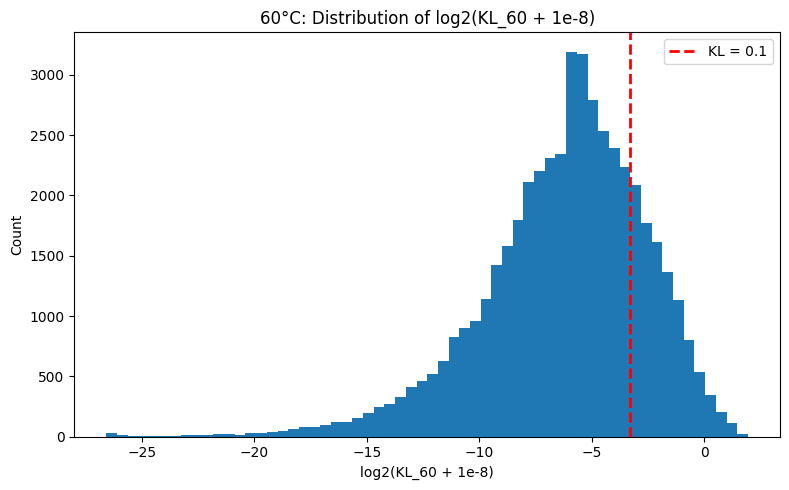

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load datasets
# =========================
df37 = pd.read_csv("../data/test_data_rna_structure.csv")
df60 = pd.read_csv("../data/test_vienna60_annotated.csv")

eps = 1e-8

# =========================
# Compute log2 KL
# =========================
df37["log2_kl"] = np.log2(
    pd.to_numeric(df37["kl"], errors="coerce") + eps
)

df60["log2_kl_60"] = np.log2(
    pd.to_numeric(df60["kl_60"], errors="coerce") + eps
)

# =========================
# KL = 0.1 threshold
# =========================
threshold = np.log2(0.1)

print("Vertical threshold at log2(0.1) =", threshold)

# =========================
# 37°C figure
# =========================
plt.figure(figsize=(8,5))

plt.hist(
    df37["log2_kl"].dropna(),
    bins=60
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label="KL = 0.1"
)

plt.title("37°C: Distribution of log2(KL + 1e-8)")
plt.xlabel("log2(KL + 1e-8)")
plt.ylabel("Count")

plt.legend()

plt.tight_layout()
plt.show()

# =========================
# 60°C figure
# =========================
plt.figure(figsize=(8,5))

plt.hist(
    df60["log2_kl_60"].dropna(),
    bins=60
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label="KL = 0.1"
)

plt.title("60°C: Distribution of log2(KL_60 + 1e-8)")
plt.xlabel("log2(KL_60 + 1e-8)")
plt.ylabel("Count")

plt.legend()

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
import numpy as np

# =========================
# Load CSVs
# =========================
df37 = pd.read_csv("../data/test_data_rna_structure.csv")
df60 = pd.read_csv("../data/test_vienna60_annotated.csv")

# =========================
# Convert to numeric
# =========================
df37["kl"] = pd.to_numeric(df37["kl"], errors="coerce")
df60["kl_60"] = pd.to_numeric(df60["kl_60"], errors="coerce")

# =========================
# Remove NaNs
# =========================
kl37 = df37["kl"].dropna()
kl60 = df60["kl_60"].dropna()

# =========================
# Summary statistics
# =========================
print("===== 37°C =====")
print("Mean KL:", kl37.mean())
print("Median KL:", kl37.median())
print("90th percentile KL:", kl37.quantile(0.90))

print("\n===== 60°C =====")
print("Mean KL:", kl60.mean())
print("Median KL:", kl60.median())
print("90th percentile KL:", kl60.quantile(0.90))

# =========================
# Relative improvement
# =========================
print("\n===== Relative Change =====")

mean_change = (kl60.mean() - kl37.mean()) / kl37.mean()
p90_change = (
    kl60.quantile(0.90) - kl37.quantile(0.90)
) / kl37.quantile(0.90)

print(f"Mean KL relative change: {mean_change:.4%}")
print(f"P90 KL relative change: {p90_change:.4%}")

===== 37°C =====
Mean KL: 0.09990419196544131
Median KL: 0.02029903212347625
90th percentile KL: 0.2682149710122982

===== 60°C =====
Mean KL: 0.09750575236888664
Median KL: 0.0181680615796823
90th percentile KL: 0.25848290941166663

===== Relative Change =====
Mean KL relative change: -2.4007%
P90 KL relative change: -3.6285%


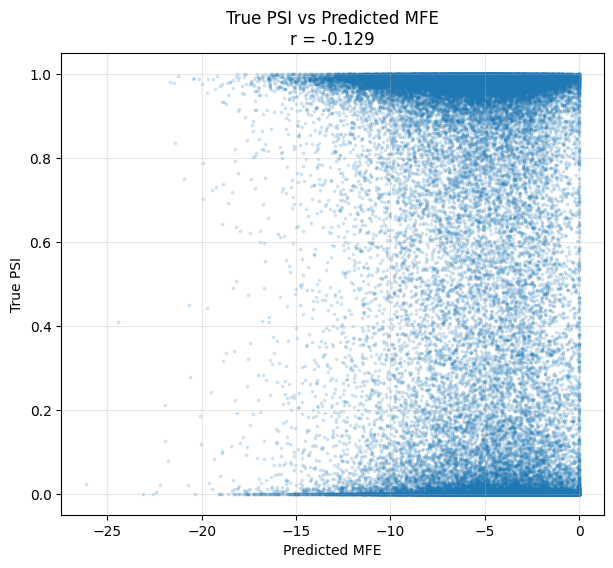

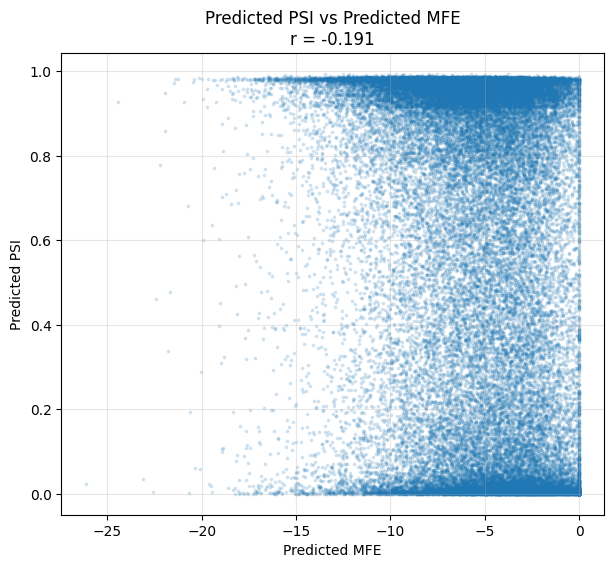

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# Load data
# =========================
df = pd.read_csv("../data/test_vienna60_annotated.csv")

# Change these if using 37C file
mfe_col = "predicted_MFE"
true_psi_col = "PSI"
pred_psi_col = "predicted_PSI_60"

# =========================
# Clean numeric columns
# =========================
for col in [mfe_col, true_psi_col, pred_psi_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[mfe_col, true_psi_col, pred_psi_col])

# =========================
# PSI vs MFE
# =========================
plt.figure(figsize=(7,6))

plt.scatter(
    df[mfe_col],
    df[true_psi_col],
    s=3,
    alpha=0.15
)

r = stats.linregress(df[mfe_col], df[true_psi_col])

plt.xlabel("Predicted MFE")
plt.ylabel("True PSI")
plt.title(f"True PSI vs Predicted MFE\nr = {r.rvalue:.3f}")

plt.grid(True, alpha=0.3)
plt.show()

# =========================
# Predicted PSI vs MFE
# =========================
plt.figure(figsize=(7,6))

plt.scatter(
    df[mfe_col],
    df[pred_psi_col],
    s=3,
    alpha=0.15
)

r = stats.linregress(df[mfe_col], df[pred_psi_col])

plt.xlabel("Predicted MFE")
plt.ylabel("Predicted PSI")
plt.title(f"Predicted PSI vs Predicted MFE\nr = {r.rvalue:.3f}")

plt.grid(True, alpha=0.3)
plt.show()

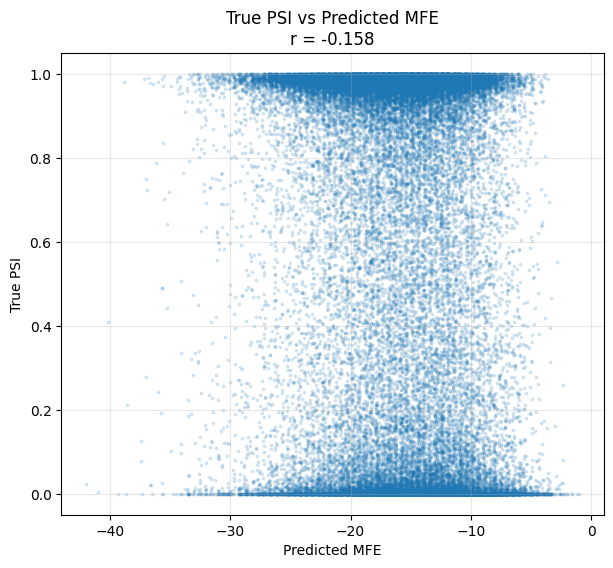

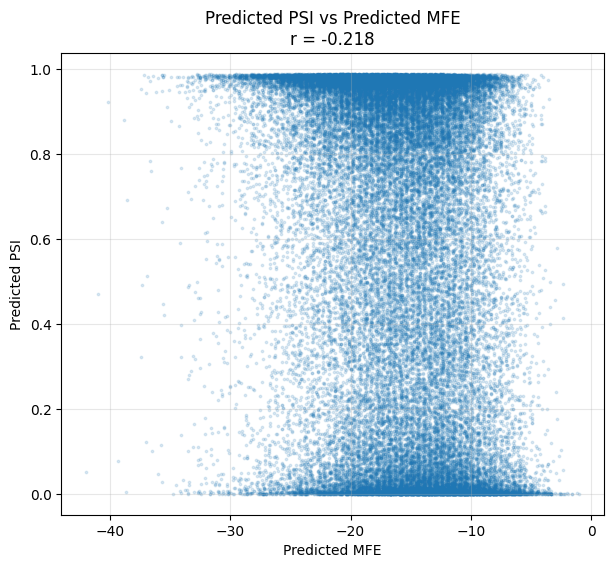

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# Load data
# =========================
df = pd.read_csv("../data/test_data_rna_structure.csv")

# Change these if using 37C file
mfe_col = "predicted_mfe"
true_psi_col = "PSI"
pred_psi_col = "predicted_PSI"

# =========================
# Clean numeric columns
# =========================
for col in [mfe_col, true_psi_col, pred_psi_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[mfe_col, true_psi_col, pred_psi_col])

# =========================
# PSI vs MFE
# =========================
plt.figure(figsize=(7,6))

plt.scatter(
    df[mfe_col],
    df[true_psi_col],
    s=3,
    alpha=0.15
)

r = stats.linregress(df[mfe_col], df[true_psi_col])

plt.xlabel("Predicted MFE")
plt.ylabel("True PSI")
plt.title(f"True PSI vs Predicted MFE\nr = {r.rvalue:.3f}")

plt.grid(True, alpha=0.3)
plt.show()

# =========================
# Predicted PSI vs MFE
# =========================
plt.figure(figsize=(7,6))

plt.scatter(
    df[mfe_col],
    df[pred_psi_col],
    s=3,
    alpha=0.15
)

r = stats.linregress(df[mfe_col], df[pred_psi_col])

plt.xlabel("Predicted MFE")
plt.ylabel("Predicted PSI")
plt.title(f"Predicted PSI vs Predicted MFE\nr = {r.rvalue:.3f}")

plt.grid(True, alpha=0.3)
plt.show()

37°C mean MFE: -16.11565676994287
60°C mean MFE: -5.636470124401332


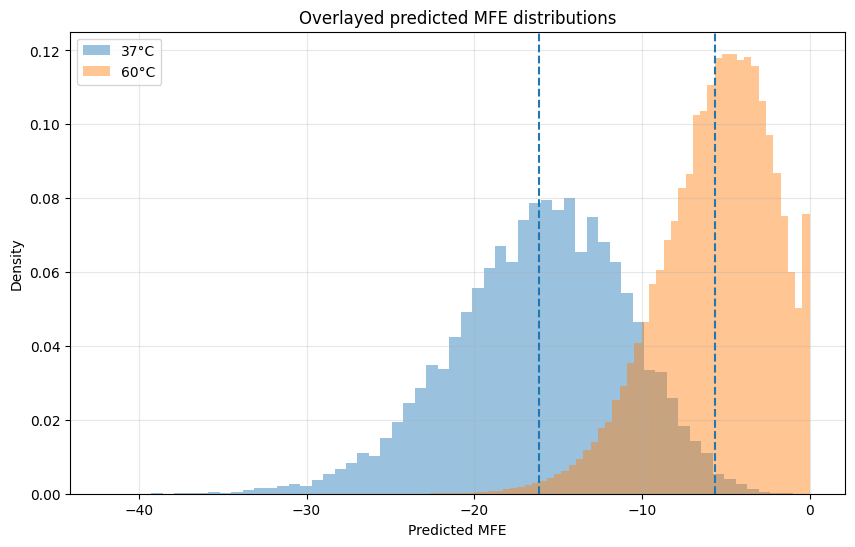

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load datasets
# -----------------------------
df37 = pd.read_csv("../data/test_data_rna_structure.csv")
df60 = pd.read_csv("../data/test_vienna60_annotated.csv")

# -----------------------------
# Create figure
# -----------------------------
plt.figure(figsize=(10, 6))

# 37C histogram
plt.hist(
    df37["predicted_mfe"],
    bins=60,
    density=True,
    alpha=0.45,
    label="37°C",
)

# 60C histogram
plt.hist(
    df60["predicted_MFE"],
    bins=60,
    density=True,
    alpha=0.45,
    label="60°C",
)

# -----------------------------
# Styling
# -----------------------------
plt.xlabel("Predicted MFE")
plt.ylabel("Density")
plt.title("Overlayed predicted MFE distributions")
plt.legend()

# Optional vertical mean lines
plt.axvline(df37["predicted_mfe"].mean(), linestyle="--")
plt.axvline(df60["predicted_MFE"].mean(), linestyle="--")

plt.grid(alpha=0.3)

# Print means
print("37°C mean MFE:", df37["predicted_mfe"].mean())
print("60°C mean MFE:", df60["predicted_MFE"].mean())

plt.show()

In [7]:
import pandas as pd
import numpy as np

# =========================
# Load CSVs
# =========================
df37 = pd.read_csv("../data/test_data_rna_structure.csv")
df60 = pd.read_csv("../data/test_vienna60_annotated.csv")
df4030 = pd.read_csv("../data/test_flank_40_30.csv")

# =========================
# Convert to numeric
# =========================
df37["kl"] = pd.to_numeric(df37["kl"], errors="coerce")
df60["kl_60"] = pd.to_numeric(df60["kl_60"], errors="coerce")
df4030["kl_flanks"] = pd.to_numeric(df4030["kl_flanks"], errors="coerce")

# =========================
# Remove NaNs
# =========================
kl37 = df37["kl"].dropna()
kl60 = df60["kl_60"].dropna()
kl4030 = df4030["kl_flanks"].dropna()

# =========================
# Summary statistics
# =========================
print("===== 37°C =====")
print("Mean KL:", kl37.mean())
print("Median KL:", kl37.median())
print("90th percentile KL:", kl37.quantile(0.90))

print("\n===== 60°C =====")
print("Mean KL:", kl60.mean())
print("Median KL:", kl60.median())
print("90th percentile KL:", kl60.quantile(0.90))

print("\n===== Flank 40/30 =====")
print("Mean KL:", kl4030.mean())
print("Median KL:", kl4030.median())
print("90th percentile KL:", kl4030.quantile(0.90))

# =========================
# Relative improvement vs 37°C baseline
# =========================
print("\n===== Relative Change vs 37°C =====")

mean_change_60 = (kl60.mean() - kl37.mean()) / kl37.mean()
p90_change_60 = (
    kl60.quantile(0.90) - kl37.quantile(0.90)
) / kl37.quantile(0.90)

mean_change_4030 = (
    kl4030.mean() - kl37.mean()
) / kl37.mean()

p90_change_4030 = (
    kl4030.quantile(0.90) - kl37.quantile(0.90)
) / kl37.quantile(0.90)

print(f"\n60°C Mean KL relative change: {mean_change_60:.4%}")
print(f"60°C P90 KL relative change: {p90_change_60:.4%}")

print(f"\nFlank 40/30 Mean KL relative change: {mean_change_4030:.4%}")
print(f"Flank 40/30 P90 KL relative change: {p90_change_4030:.4%}")

===== 37°C =====
Mean KL: 0.09990419196544131
Median KL: 0.02029903212347625
90th percentile KL: 0.2682149710122982

===== 60°C =====
Mean KL: 0.09750575236888664
Median KL: 0.0181680615796823
90th percentile KL: 0.25848290941166663

===== Flank 40/30 =====
Mean KL: 0.10397117817173877
Median KL: 0.0190171245041018
90th percentile KL: 0.27781711549828336

===== Relative Change vs 37°C =====

60°C Mean KL relative change: -2.4007%
60°C P90 KL relative change: -3.6285%

Flank 40/30 Mean KL relative change: 4.0709%
Flank 40/30 P90 KL relative change: 3.5800%
